# MAE 预训练补全演示

重建演示使用 **3 张固定 PNG**（Sugar-Beets `img_350_crop_ews_y`，已对齐 EWS 亮度），路径在首格 **`DEMO_RECON_PATHS`** 中配置。**不使用 patch list**。

读入后为 **350×350 RGB**；若与 checkpoint 的 `img_size` 不一致会双线性缩放。每种状态单独一张图（3×4 共 **12** 幅），不画 patch 网格线。

- **原图**
- **遮盖示意**
- **模型重建整图**
- **仅在 mask 区域用预测值、其余用原图**

支持 **`mae2d_best.pt`** 与 **`mae2d_geom_best.pt`**（`CKPT_PREFER`）。


In [60]:
from pathlib import Path


def find_repo(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "EWS" / "pretrain" / "mae2d.py").is_file():
            return p
    raise FileNotFoundError("请在包含 EWS/pretrain 的仓库根目录下打开本 notebook。")


REPO = find_repo(Path.cwd())
PRETRAIN_DATA = REPO / "EWS" / "data" / "pretrain"
CKPT_DIR = PRETRAIN_DATA / "checkpoints"
CKPT_DIR_GEOM = PRETRAIN_DATA / "checkpoints_geom"

CKPT_VANILLA = CKPT_DIR / "mae2d_best.pt"
CKPT_GEOM = CKPT_DIR_GEOM / "mae2d_geom_best.pt"

# 重建演示：3 张固定图（350×350，img_350_crop_ews_y）
DEMO_RECON_PATHS = [
    Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame0.png"),
    Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame1.png"),
    Path(r"D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame2.png"),
]

CKPT_OVERRIDE = None
CKPT_PREFER = "geom"  # "vanilla" | "geom"

for i, fp in enumerate(DEMO_RECON_PATHS):
    print(f"demo image {i}:", fp, fp.is_file())
print("ckpt vanilla:", CKPT_VANILLA, CKPT_VANILLA.is_file())
print("ckpt geom:", CKPT_GEOM, CKPT_GEOM.is_file())


demo image 0: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame0.png True
demo image 1: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame1.png True
demo image 2: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame2.png True
ckpt vanilla: D:\Cursor\UNSW-COMP-9517\EWS\data\pretrain\checkpoints\mae2d_best.pt True
ckpt geom: D:\Cursor\UNSW-COMP-9517\EWS\data\pretrain\checkpoints_geom\mae2d_geom_best.pt True


In [61]:
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

PRE = REPO / "EWS" / "pretrain"
if str(PRE) not in sys.path:
    sys.path.insert(0, str(PRE))

from mae2d import MaskedAutoencoder2D
from mae2d_geom import MaskedAutoencoder2DGeom

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [62]:
def pick_checkpoint() -> Path:
    if CKPT_OVERRIDE is not None and Path(CKPT_OVERRIDE).is_file():
        return Path(CKPT_OVERRIDE)
    prefer = str(CKPT_PREFER).strip().lower()
    first = CKPT_GEOM if prefer == "geom" else CKPT_VANILLA
    second = CKPT_VANILLA if prefer == "geom" else CKPT_GEOM
    if first.is_file():
        return first
    if second.is_file():
        return second
    raise FileNotFoundError(
        "未找到 checkpoint。请先完成预训练或设置 CKPT_OVERRIDE 指向 .pt 文件。"
    )


def build_model_from_ckpt(ckpt: dict) -> torch.nn.Module:
    args = ckpt.get("args") or {}
    img_size = int(args.get("img_size", 350))
    patch_size = int(args.get("patch_size", 5))
    arch = ckpt.get("arch")
    if arch == "MaskedAutoencoder2DGeom":
        use_geom = ckpt.get("use_geom_bias", True)
        if "no_geom_bias" in args:
            use_geom = not bool(args["no_geom_bias"])
        return MaskedAutoencoder2DGeom(
            img_size=img_size, patch_size=patch_size, use_geom_bias=use_geom
        )
    # 无 arch 字段时按 vanilla 构建
    return MaskedAutoencoder2D(img_size=img_size, patch_size=patch_size)


def load_model(ckpt_path: Path) -> tuple[torch.nn.Module, dict]:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    sd = ckpt["model"]
    model = build_model_from_ckpt(ckpt)
    try:
        model.load_state_dict(sd, strict=True)
    except Exception:
        if isinstance(model, MaskedAutoencoder2DGeom):
            model = MaskedAutoencoder2D(
                img_size=int((ckpt.get("args") or {}).get("img_size", 350)),
                patch_size=int((ckpt.get("args") or {}).get("patch_size", 5)),
            )
            model.load_state_dict(sd, strict=True)
        else:
            model = MaskedAutoencoder2DGeom(
                img_size=int((ckpt.get("args") or {}).get("img_size", 350)),
                patch_size=int((ckpt.get("args") or {}).get("patch_size", 5)),
                use_geom_bias=not bool((ckpt.get("args") or {}).get("no_geom_bias", False)),
            )
            model.load_state_dict(sd, strict=True)
    model.eval()
    model.to(device)
    return model, ckpt


def unpatchify(model: torch.nn.Module, x: torch.Tensor) -> torch.Tensor:
    """x: (B, L, patch_dim) -> (B, 3, H, W)"""
    b, l, pdim = x.shape
    p = model.patch_size
    g = model.grid
    c = model.in_chans
    x = x.reshape(b, g, g, p, p, c)
    x = torch.einsum("nhwpqc->nchpwq", x)
    return x.reshape(b, c, g * p, g * p)


def mask_to_pixel_mask(model: torch.nn.Module, mask_1d: torch.Tensor) -> torch.Tensor:
    """mask_1d: (B, L) 1=masked patch -> (B, 1, H, W) float for broadcasting.

    Must match Conv2d patch order / unpatchify: pixel (H,W) = (i*p+dr, j*p+dc), not patch-major flatten.
    """
    b, l = mask_1d.shape
    g = model.grid
    p = model.patch_size
    m = mask_1d.reshape(b, g, g, 1, 1, 1).expand(b, g, g, p, p, 3)
    m = m.reshape(b, g, g, p, p, 3).permute(0, 1, 3, 2, 4, 5).contiguous()
    m = m.reshape(b, g * p, g * p, 3).permute(0, 3, 1, 2)
    return (m[:, :1] > 0).float()


def to_show(t: torch.Tensor) -> np.ndarray:
    """(3,H,W) [0,1] -> HWC float for imshow"""
    x = t.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
    return x


def draw_patch_grid(
    ax,
    model: torch.nn.Module,
    *,
    color: str = "white",
    lw: float = 0.7,
    alpha: float = 0.9,
) -> None:
    """Draw patch grid (model.patch_size) on top of the last imshow."""
    p = int(model.patch_size)
    g = int(model.grid)
    z = 10
    for i in range(1, g):
        ax.axvline(i * p, color=color, lw=lw, alpha=alpha, zorder=z)
    for j in range(1, g):
        ax.axhline(j * p, color=color, lw=lw, alpha=alpha, zorder=z)


ckpt_path = pick_checkpoint()
print("using checkpoint:", ckpt_path)
model, ckpt_meta = load_model(ckpt_path)
# 演示前向的 mask 比例（可自行修改，例如 0.75）
MASK_RATIO = 0.75

args = ckpt_meta.get("args") or {}
img_size = int(args.get("img_size", model.img_size))
mask_ratio = float(MASK_RATIO)
print("mask_ratio (demo):", mask_ratio, "img_size:", img_size)

using checkpoint: D:\Cursor\UNSW-COMP-9517\EWS\data\pretrain\checkpoints_geom\mae2d_geom_best.pt
mask_ratio (demo): 0.75 img_size: 350


sample 1/3: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame0.png
  loss: 0.009073


C:\Users\hrole\AppData\Local\Temp\ipykernel_3980\1088320538.py:45: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hrole\AppData\Local\Temp\ipykernel_3980\1088320538.py:45: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


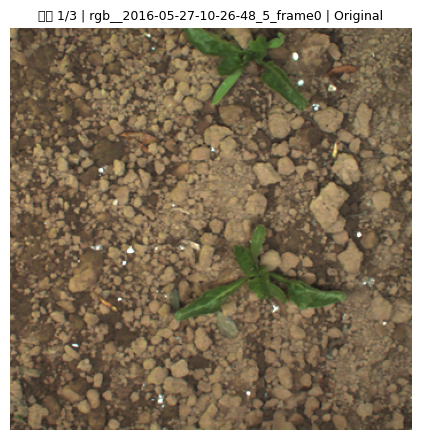

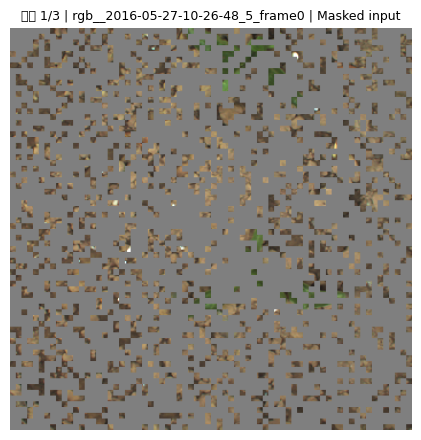

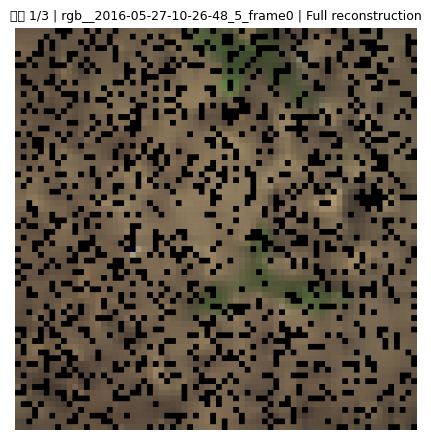

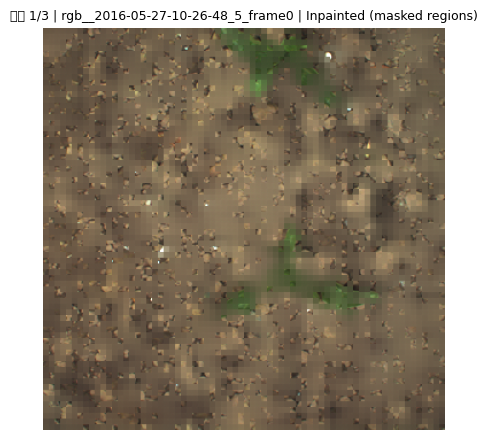

sample 2/3: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame1.png
  loss: 0.008963


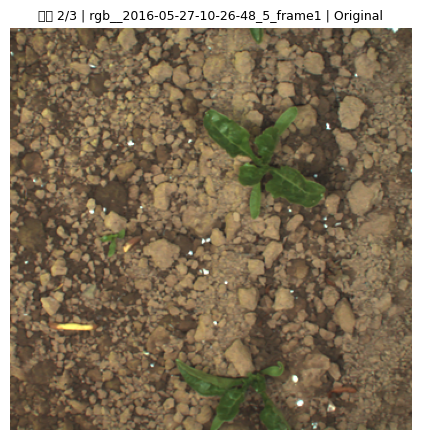

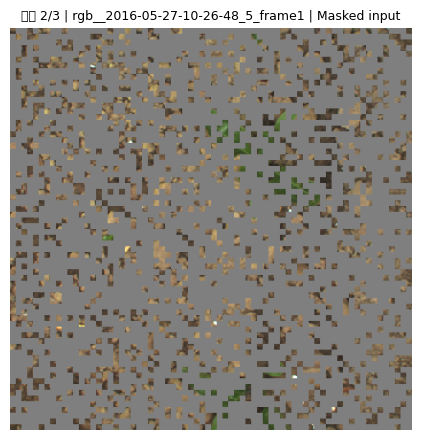

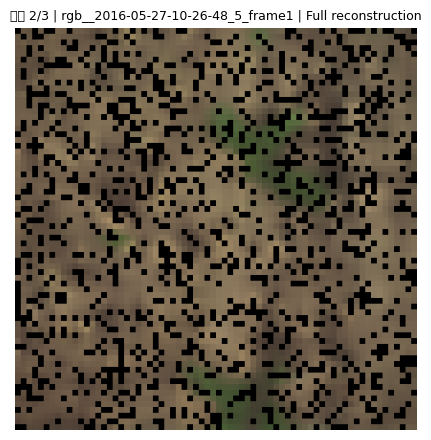

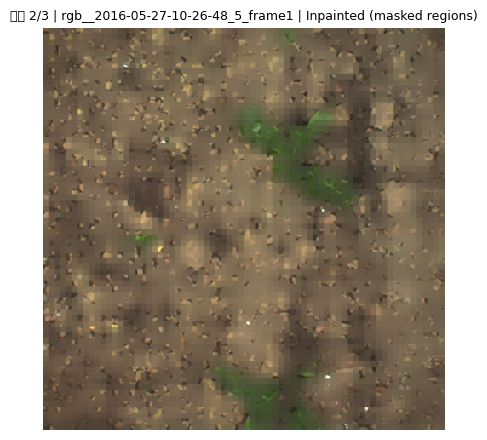

sample 3/3: D:\Cursor\UNSW-COMP-9517\EWS\data\sugar-beets-2016-DatasetNinja\ds\img_350_crop_ews_y\rgb__2016-05-27-10-26-48_5_frame2.png
  loss: 0.008651


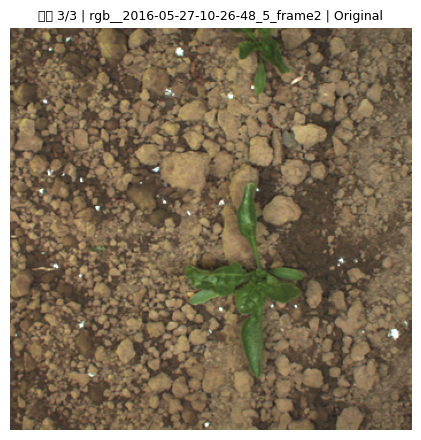

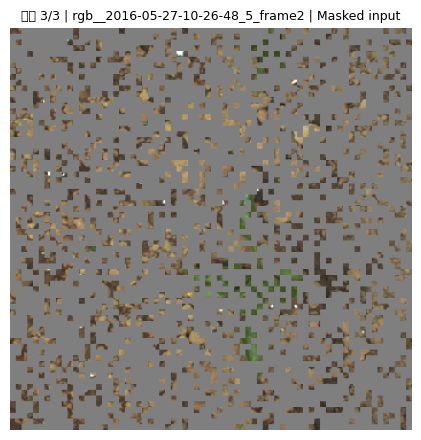

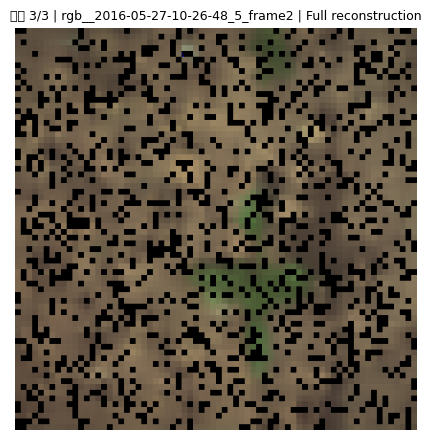

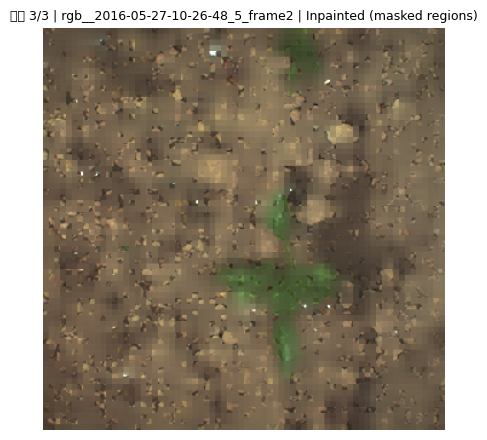

In [63]:
paths_pick = list(DEMO_RECON_PATHS)
NUM_SAMPLES = len(paths_pick)

for fp in paths_pick:
    if not fp.is_file():
        raise FileNotFoundError(f"演示图片不存在: {fp}")

titles = ["Original", "Masked input", "Full reconstruction", "Inpainted (masked regions)"]

for row, path_one in enumerate(paths_pick):
    print(f"sample {row + 1}/{NUM_SAMPLES}:", path_one)
    im = Image.open(path_one).convert("RGB")
    arr = np.asarray(im).astype(np.float32) / 255.0
    img = torch.from_numpy(arr).permute(2, 0, 1).contiguous()
    if img.shape[1] != img_size or img.shape[2] != img_size:
        img = torch.nn.functional.interpolate(
            img.unsqueeze(0),
            size=(img_size, img_size),
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)
    img = img.clamp(0, 1)
    batch = img.unsqueeze(0).to(device)

    with torch.no_grad():
        loss, pred, mask = model(batch, mask_ratio=mask_ratio)

    print(f"  loss: {float(loss.item()):.6f}")

    recon = unpatchify(model, pred).squeeze(0)
    pm = mask_to_pixel_mask(model, mask)
    gray = torch.full_like(batch, 0.5)
    masked_vis = batch * (1 - pm) + gray * pm
    blend = batch * (1 - pm) + recon.unsqueeze(0) * pm

    stem = Path(path_one).stem
    for t, title in zip(
        [batch, masked_vis, recon.unsqueeze(0), blend],
        titles,
    ):
        fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
        ax.imshow(to_show(t.squeeze(0)))
        ax.set_title(f"样本 {row + 1}/{NUM_SAMPLES} | {stem} | {title}", fontsize=9)
        ax.axis("off")
        plt.tight_layout()
        plt.show()


In [ ]:
# 固定3 张中取1 张做分通道百分位拉伸示意
_p = random.choice(list(DEMO_RECON_PATHS))
print("sample:", _p)

im = Image.open(_p).convert("RGB")
_arr = np.asarray(im).astype(np.float32) / 255.0
if _arr.ndim != 3 or _arr.shape[-1] != 3:
    raise ValueError(f"Expected (H,W,3), got {_arr.shape}")

P_LO, P_HI = 3.0, 97.0
_vis = np.empty_like(_arr)
for _c in range(3):
    _ch = _arr[..., _c]
    _lo, _hi = np.percentile(_ch, (P_LO, P_HI))
    if _hi <= _lo:
        _lo, _hi = float(_ch.min()), float(_ch.max())
    _vis[..., _c] = np.clip((_ch - _lo) / (_hi - _lo + 1e-8), 0.0, 1.0)

plt.figure(figsize=(6, 6))
plt.imshow(_vis)
plt.axis("off")
plt.title("Fixed demo RGB (contrast stretch)")
plt.tight_layout()
plt.show()
